<a href="https://colab.research.google.com/github/vishnuvardhan1699/2520030392_ML/blob/main/Project/EDA_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd
import seaborn as sns

In [1]:

from pandas import read_csv
df=read_csv("/content/Crop_recommendation (1).csv")

In [4]:
# Numerical vs Categorical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Categorical Features: ['label']


In [5]:
# Select only numerical columns for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [6]:
# Print matrix to terminal
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.231460 -0.140512     0.026504  0.190688  0.096683   
P           -0.231460  1.000000  0.736232    -0.127541 -0.118734 -0.138019   
K           -0.140512  0.736232  1.000000    -0.160387  0.190859 -0.169503   
temperature  0.026504 -0.127541 -0.160387     1.000000  0.205320 -0.017795   
humidity     0.190688 -0.118734  0.190859     0.205320  1.000000 -0.008483   
ph           0.096683 -0.138019 -0.169503    -0.017795 -0.008483  1.000000   
rainfall     0.059020 -0.063839 -0.053461    -0.030084  0.094423 -0.109069   

             rainfall  
N            0.059020  
P           -0.063839  
K           -0.053461  
temperature -0.030084  
humidity     0.094423  
ph          -0.109069  
rainfall     1.000000  


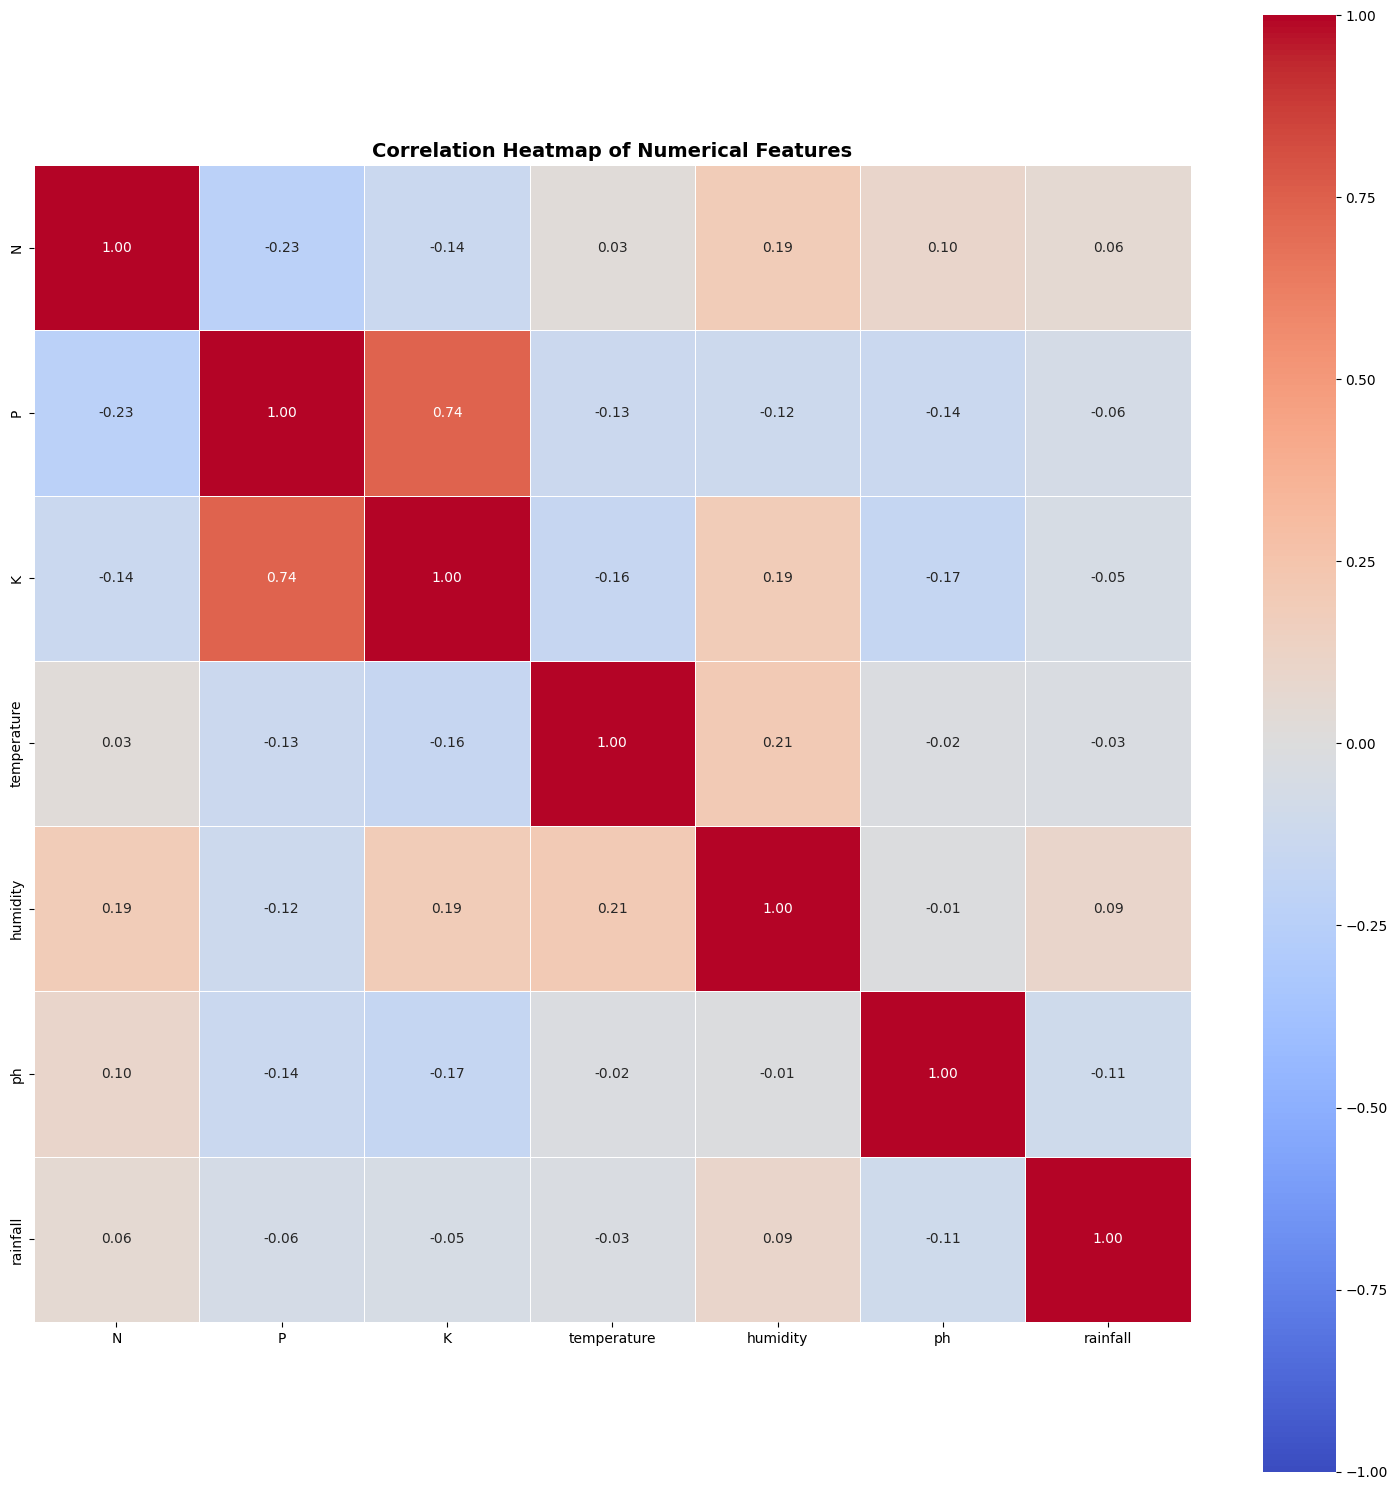

In [7]:
# Create Heatmap
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [8]:

# Export Heatmap
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [10]:
# -------------------------------------------------------------
# 3. Produce Boxplots: Numerical Features vs PlacementStatus
# -------------------------------------------------------------
target_col = "PlacementStatus"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()


        # Save the boxplot
        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"

        # Create complete file path
        boxplot_path = os.path.join(output_dir, boxplot_filename)

        # Save the figure
        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")

        # Close the figure
        plt.close()

        # Display confirmation message
        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")



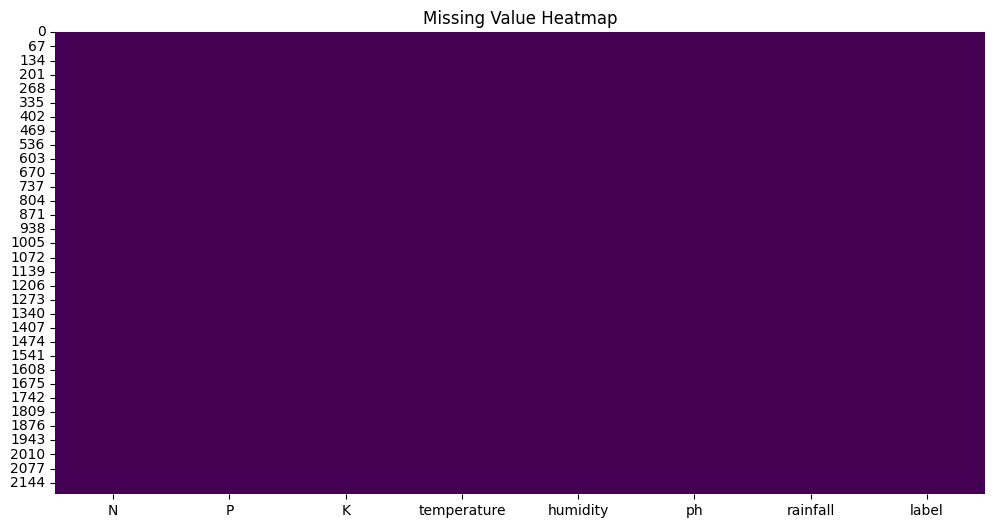

In [11]:
import matplotlib.pyplot as plt
fig1=plt.figure(figsize=(12,6))

sns.heatmap(
         df.isnull(),
        cbar=False,
         cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

<Figure size 1500x800 with 0 Axes>

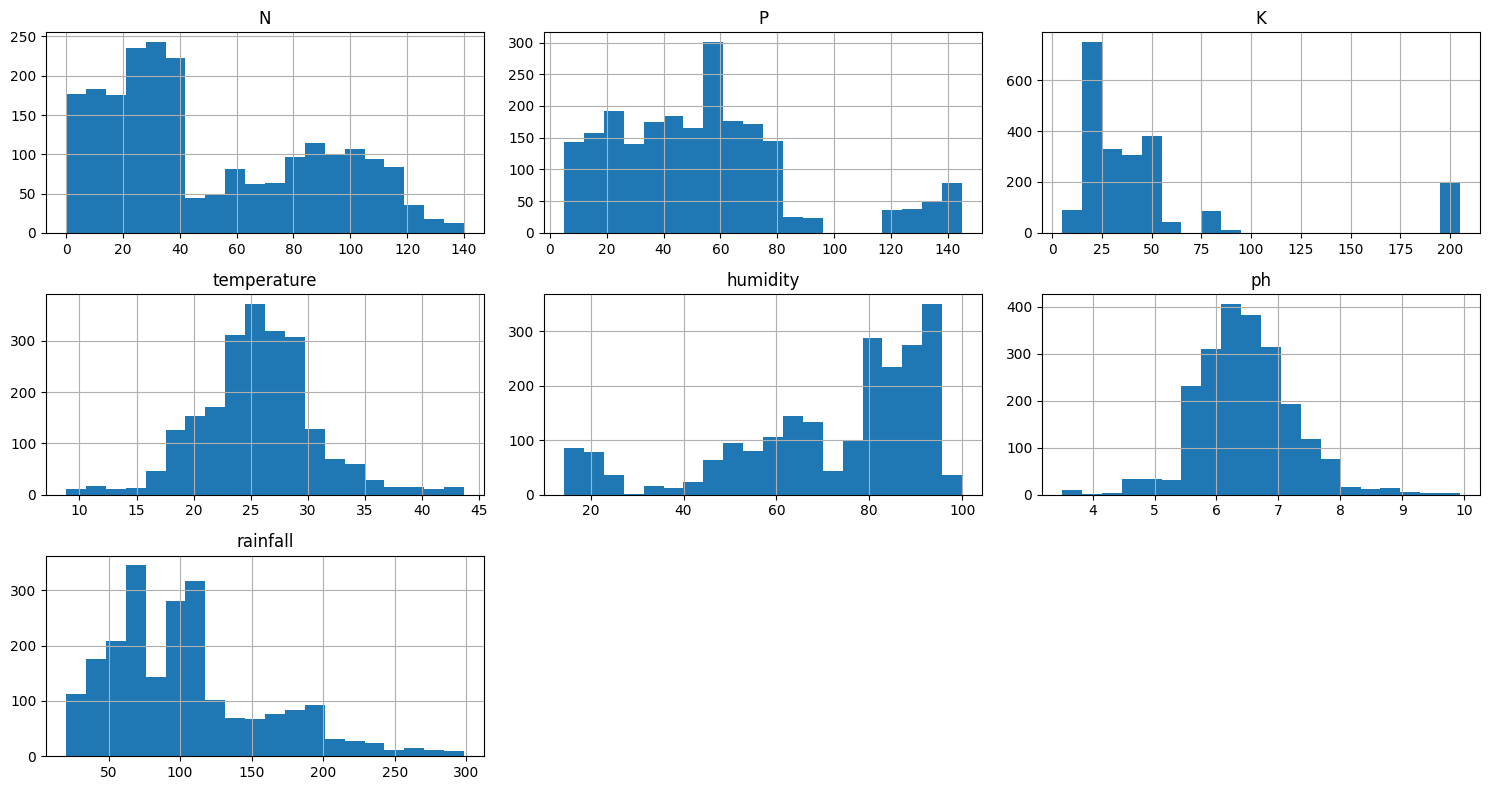

In [14]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

fig2 = plt.figure(figsize=(15, 8))

df[features].hist(
    bins=20,
    figsize=(15, 8)
)

plt.tight_layout()
plt.show()

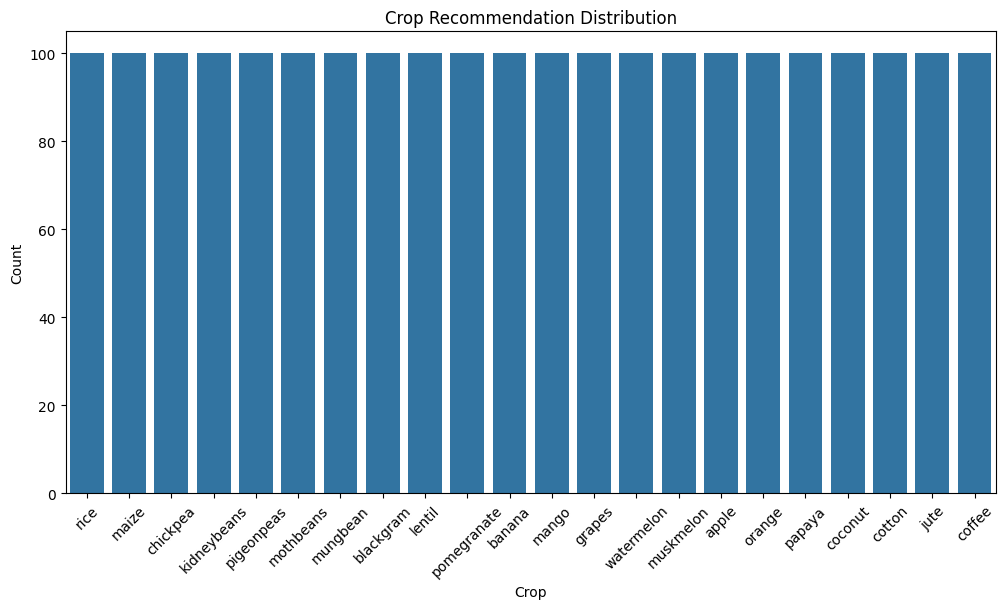

In [15]:
# Crop recommendation by crop type

fig3 = plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Crop Recommendation Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

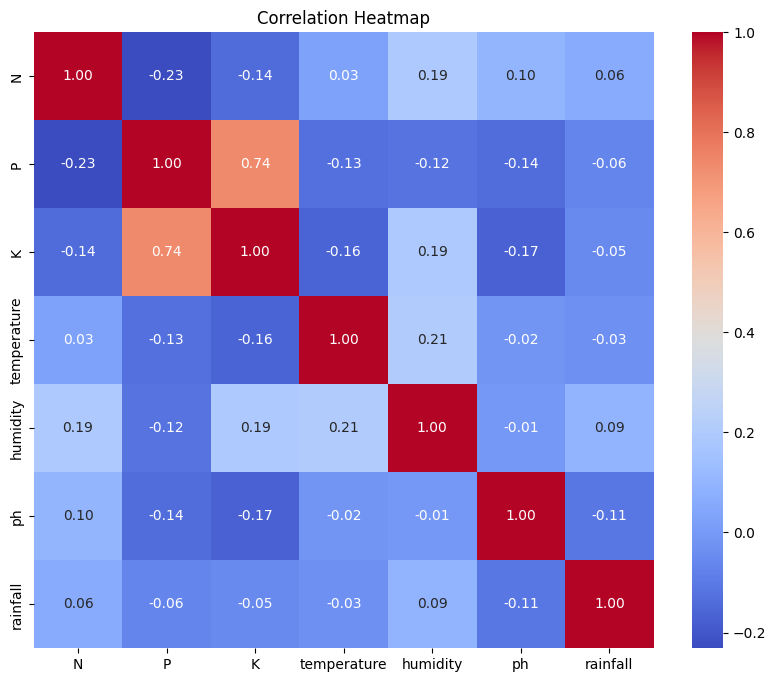

In [16]:
#Corelation Heatmap

fig5= plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

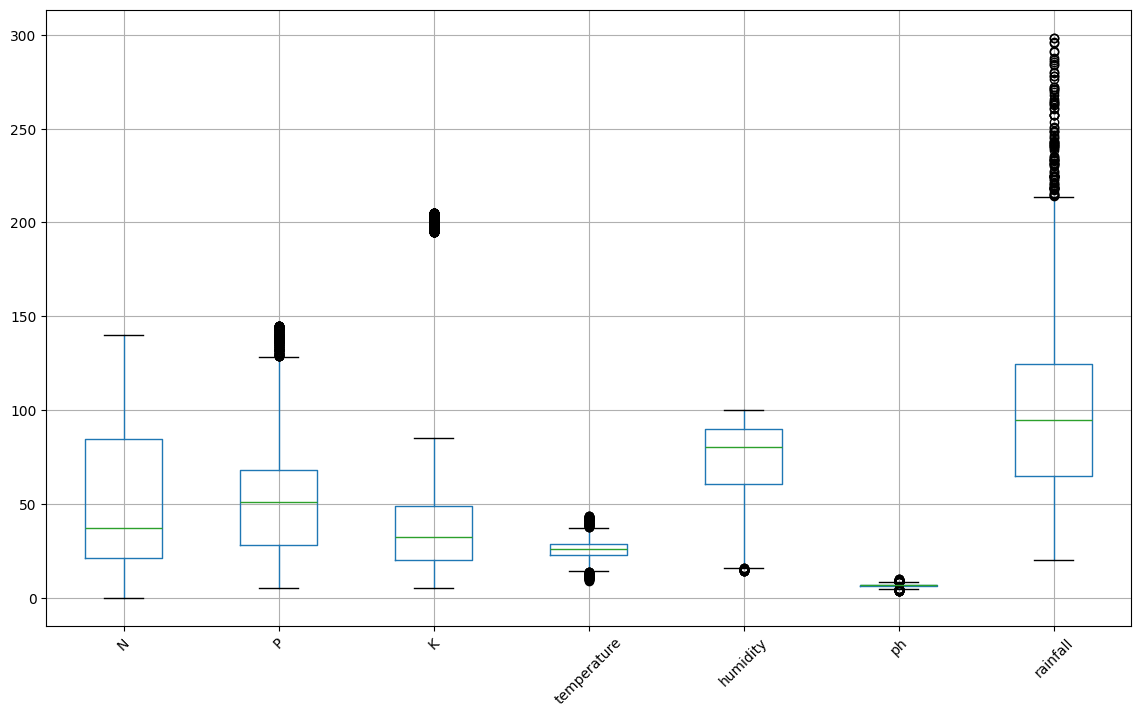

In [17]:
# Boxplots

numerical_columns = [
    "N",
    "P",
    "K",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
]

fig6 = plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.show()

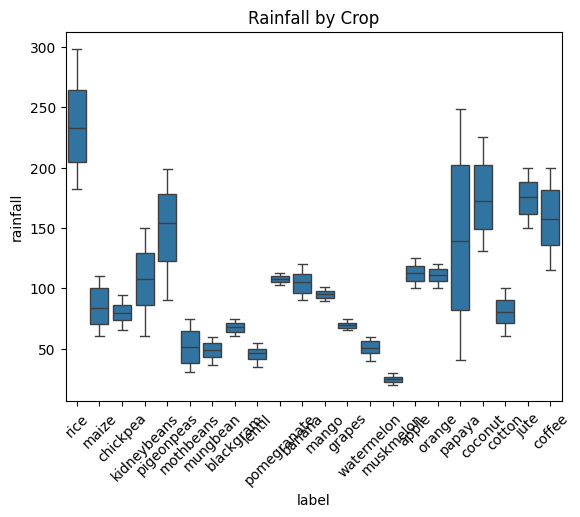

In [18]:
fig7 = sns.boxplot(x='label', y='rainfall', data=df)

plt.title("Rainfall by Crop")
plt.xticks(rotation=45)
plt.show()

In [19]:
from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("EDA_Report.pdf") as pdf:

    pdf.savefig(fig1)
    pdf.savefig(fig2)
    pdf.savefig(fig3)
    pdf.savefig(fig5)
    pdf.savefig(fig6)


print("EDA Report saved successfully.")

EDA Report saved successfully.
